# Part I -- Stages 2 & 3: Multiple Linear Regression and Model Selection

## Data and Feature Engineering

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
tickers = ["^IXIC", "AAPL", "GOOGL"]
data = yf.download(tickers, start="2021-01-01", end="2026-06-01")

close = data['Close']
volume = data['Volume']

log_returns = np.log(close / close.shift(1))
volume_change = np.log(volume / volume.shift(1))

[                       0%                       ]

[**********************67%*******                ]  2 of 3 completed

[*********************100%***********************]  3 of 3 completed

In [3]:
df = pd.DataFrame(index=log_returns.index)

df['AAPL'] = log_returns['AAPL']                                   # AAPL return at t (target)
df['IXIC_lag1'] = log_returns['^IXIC'].shift(1)                    # NASDAQ return at t-1
df['AAPL_lag1'] = log_returns['AAPL'].shift(1)                     # AAPL's own return at t-1

for window in [20, 50, 200]:
    df[f'MA{window}'] = log_returns['AAPL'].rolling(window).mean().shift(1)   # moving average of past returns
    df[f'Vol{window}'] = log_returns['AAPL'].rolling(window).std().shift(1)   # rolling volatility of past returns

df['VolumeChg_lag1'] = volume_change['AAPL'].shift(1)                                          # AAPL trading volume change at t-1
df['VolumeRatio_lag1'] = (volume['AAPL'] / volume['AAPL'].rolling(20).mean()).shift(1)         # AAPL volume relative to its 20-day average, at t-1

df = df.dropna()
df.head()

,AAPL,IXIC_lag1,AAPL_lag1,MA20,Vol20,MA50,Vol50,MA200,Vol200,VolumeChg_lag1,VolumeRatio_lag1
Date,,,,,,,,,,,
2021-10-20,0.003355,0.007116,0.014968,0.001824,0.012595,0.000362,0.013026,0.000720,0.015735,-0.113853,0.995088
2021-10-21,0.001473,-0.000490,0.003355,0.001156,0.012108,0.000497,0.013021,0.000676,0.015715,-0.268069,0.770121
2021-10-22,-0.005299,0.006198,0.001473,0.000894,0.012038,0.000490,0.013021,0.000854,0.015518,0.050114,0.811526
2021-10-25,-0.000337,-0.008282,-0.005299,0.000599,0.012118,-0.000027,0.012717,0.000660,0.015348,-0.042193,0.775230
2021-10-26,0.004564,0.009006,-0.000337,0.001112,0.011832,-0.000062,0.012715,0.000615,0.015338,-0.149227,0.678223


### Feature Normalization

The predictors live on very different scales: `MA200`/`Vol200` are smoothed over 200 days and
have much smaller variance than `MA20`/`Vol20`, and `VolumeChg_lag1` (a log volume change) is on
a different scale than the return-based features. To make the regression coefficients
comparable (each coefficient becomes "effect of a 1-standard-deviation change in that
predictor"), all predictors are standardized (z-scored: zero mean, unit variance). The target
`AAPL` is left in its original units (log returns) so the fitted equation stays interpretable.

In [4]:
feature_cols = ['IXIC_lag1', 'AAPL_lag1', 'MA20', 'MA50', 'MA200', 'Vol20', 'Vol50', 'Vol200', 'VolumeChg_lag1', 'VolumeRatio_lag1']

df_z = df.copy()
df_z[feature_cols] = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std()

df_z.describe().loc[['mean', 'std']]

,AAPL,IXIC_lag1,AAPL_lag1,MA20,Vol20,MA50,Vol50,MA200,Vol200,VolumeChg_lag1,VolumeRatio_lag1
mean,0.000662,1.843969e-17,-3.841602e-18,3.073282e-18,9.834502e-17,-9.219845e-18,4.671388e-16,-4.917251e-17,-6.884151e-16,-1.037233e-17,2.231971e-16
std,0.017573,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


## Stage 2: Multiple Linear Regression

### Model A: Full Lagged Model

Every predictor now uses only information available **before** day $t$ (the contemporaneous
index return `IXIC` from Stage 1 is replaced by its $t-1$ value), so Model A is a genuine
*forecasting* model: can AAPL's return be predicted using only past information? All
predictors are the standardized (z-scored) versions from `df_z`.

$$\text{AAPL}_t = \beta_0 + \beta_1 \text{IXIC}_{t-1} + \beta_2 \text{AAPL}_{t-1} + \sum_{w \in \{20,50,200\}} \left(\gamma_w \text{MA}w_{t-1} + \delta_w \text{Vol}w_{t-1}\right) + \beta_9 \Delta\text{Volume}_{t-1} + \beta_{10} \text{VolRatio}_{t-1} + \varepsilon_t$$

In [5]:
y = df_z['AAPL']
X_A = sm.add_constant(df_z[feature_cols])

modelA = sm.OLS(y, X_A).fit()
modelA.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   AAPL   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.130
Date:                Sun, 14 Jun 2026   Prob (F-statistic):              0.336
Time:                        18:05:32   Log-Likelihood:                 3037.7
No. Observations:                1156   AIC:                            -6053.
Df Residuals:                    1145   BIC:                            -5998.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0007      0.001      1.281      0.200      -0.000       0.002
IXIC_lag1           -0.0009      0.001     -1.164      0.245      -0.003       0.001
AAPL_lag1            0.0012      0.001      1.477      0.140      -0.000       0.003
MA20              5.847e-05      0.001      0.087      0.931      -0.001       0.001
MA50                -0.0003      0.001     -0.435      0.664      -0.002       0.001
MA200               -0.0012      0.001     -1.585      0.113      -0.003       0.000
Vol20               -0.0006      0.001     -0.759      0.448      -0.002       0.001
Vol50               -0.0004      0.001     -0.381      0.703      -0.002       0.002
Vol200              -0.0001      0.001     -0.179      0.858      -0.002       0.001
VolumeChg_lag1      -0.0013      0.001     -2.158      0.031      -0.003      -0.000
VolumeRatio_lag1     0.0007      0.001      1.193      0.233      -0.000       0.002
==============================================================================
Omnibus:                      162.080   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1558.822
Skew:                           0.276   Prob(JB):                         0.00
Kurtosis:                       8.662   Cond. No.                         4.11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
print(f"R-squared:          {modelA.rsquared:.4f}")
print(f"Adjusted R-squared: {modelA.rsquared_adj:.4f}")
print(f"AIC:                {modelA.aic:.2f}")
print(f"BIC:                {modelA.bic:.2f}")
print()
print(modelA.pvalues.round(4))

R-squared:          0.0098
Adjusted R-squared: 0.0011
AIC:                -6053.44
BIC:                -5997.86

const               0.2005
IXIC_lag1           0.2447
AAPL_lag1           0.1401
MA20                0.9308
MA50                0.6640
MA200               0.1133
Vol20               0.4481
Vol50               0.7032
Vol200              0.8576
VolumeChg_lag1      0.0312
VolumeRatio_lag1    0.2332
dtype: float64


### Multicollinearity Check (Model A)

`MA20`/`MA50`/`MA200` (and `Vol20`/`Vol50`/`Vol200`) are rolling statistics of the same
underlying series over overlapping windows, so they are likely highly correlated with each
other. Variance Inflation Factors (VIF) quantify this.

In [7]:
vif = pd.Series(
    [variance_inflation_factor(X_A.values, i) for i in range(X_A.shape[1])],
    index=X_A.columns,
)
vif

const               1.000000
IXIC_lag1           2.425474
AAPL_lag1           2.510347
MA20                1.697806
MA50                2.264133
MA200               2.309482
Vol20               2.663698
Vol50               3.441838
Vol200              2.063349
VolumeChg_lag1      1.437844
VolumeRatio_lag1    1.469158
dtype: float64

### Model B: Reduced Model

Model A (all-lagged) has overall F-test $p = 0.336$ -- essentially nothing is predictable from
purely past information. Model B mirrors the classic two-predictor specification from Stage 1
(market index return + own lagged return), now both at $t-1$, to test this minimal forecasting
model directly.

$$\text{AAPL}_t = \beta_0 + \beta_1 \cdot \text{IXIC}_{t-1} + \beta_2 \cdot \text{AAPL}_{t-1} + \varepsilon_t$$

In [8]:
X_B = sm.add_constant(df_z[['IXIC_lag1', 'AAPL_lag1']])

modelB = sm.OLS(y, X_B).fit()
modelB.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   AAPL   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6824
Date:                Sun, 14 Jun 2026   Prob (F-statistic):              0.506
Time:                        18:05:32   Log-Likelihood:                 3032.7
No. Observations:                1156   AIC:                            -6059.
Df Residuals:                    1153   BIC:                            -6044.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      1.280      0.201      -0.000       0.002
IXIC_lag1     -0.0007      0.001     -0.872      0.383      -0.002       0.001
AAPL_lag1      0.0009      0.001      1.168      0.243      -0.001       0.002
==============================================================================
Omnibus:                      171.670   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1796.638
Skew:                           0.294   Prob(JB):                         0.00
Kurtosis:                       9.079   Cond. No.                         2.72
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
print(f"R-squared:          {modelB.rsquared:.4f}")
print(f"Adjusted R-squared: {modelB.rsquared_adj:.4f}")
print(f"AIC:                {modelB.aic:.2f}")
print(f"BIC:                {modelB.bic:.2f}")
print()
print(modelB.pvalues.round(4))

R-squared:          0.0012
Adjusted R-squared: -0.0006
AIC:                -6059.46
BIC:                -6044.30

const        0.2008
IXIC_lag1    0.3832
AAPL_lag1    0.2431
dtype: float64


### Model C: Volume-Focused Model

**Question:** Can trading volume explain/predict returns? In Model A, `VolumeChg_lag1` was
the *only* predictor with $p < 0.05$. Model C isolates the volume-related predictors --
day-over-day volume change and the volume *level* relative to its 20-day average -- alongside
the own lagged return, to test this question more directly.

$$\text{AAPL}_t = \beta_0 + \beta_1 \cdot \text{AAPL}_{t-1} + \beta_2 \cdot \Delta\text{Volume}_{t-1} + \beta_3 \cdot \text{VolRatio}_{t-1} + \varepsilon_t$$

In [10]:
X_C = sm.add_constant(df_z[['AAPL_lag1', 'VolumeChg_lag1', 'VolumeRatio_lag1']])

modelC = sm.OLS(y, X_C).fit()
modelC.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   AAPL   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.768
Date:                Sun, 14 Jun 2026   Prob (F-statistic):              0.152
Time:                        18:05:32   Log-Likelihood:                 3034.7
No. Observations:                1156   AIC:                            -6061.
Df Residuals:                    1152   BIC:                            -6041.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0007      0.001      1.282      0.200      -0.000       0.002
AAPL_lag1            0.0004      0.001      0.720      0.471      -0.001       0.001
VolumeChg_lag1      -0.0013      0.001     -2.148      0.032      -0.003      -0.000
VolumeRatio_lag1     0.0009      0.001      1.411      0.158      -0.000       0.002
==============================================================================
Omnibus:                      162.427   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1577.406
Skew:                           0.273   Prob(JB):                         0.00
Kurtosis:                       8.697   Cond. No.                         1.84
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
print(f"R-squared:          {modelC.rsquared:.4f}")
print(f"Adjusted R-squared: {modelC.rsquared_adj:.4f}")
print(f"AIC:                {modelC.aic:.2f}")
print(f"BIC:                {modelC.bic:.2f}")
print()
print(modelC.pvalues.round(4))

R-squared:          0.0046
Adjusted R-squared: 0.0020
AIC:                -6061.40
BIC:                -6041.19

const               0.2003
AAPL_lag1           0.4714
VolumeChg_lag1      0.0319
VolumeRatio_lag1    0.1584
dtype: float64


## Stage 3: Model Evaluation and Selection

### Model Comparison

In [12]:
comparison = pd.DataFrame({
    'Model A (full lagged)': [modelA.rsquared, modelA.rsquared_adj, modelA.aic, modelA.bic],
    'Model B (reduced)': [modelB.rsquared, modelB.rsquared_adj, modelB.aic, modelB.bic],
    'Model C (volume-focused)': [modelC.rsquared, modelC.rsquared_adj, modelC.aic, modelC.bic],
}, index=['R-squared', 'Adj. R-squared', 'AIC', 'BIC'])

comparison

,Model A (full lagged),Model B (reduced),Model C (volume-focused)
R-squared,0.009769,0.001182,0.004582
Adj. R-squared,0.001121,-0.000550,0.001990
AIC,-6053.441330,-6059.460301,-6061.401480
BIC,-5997.861398,-6044.302138,-6041.190596


### Residual Diagnostics (Model C, lowest AIC)

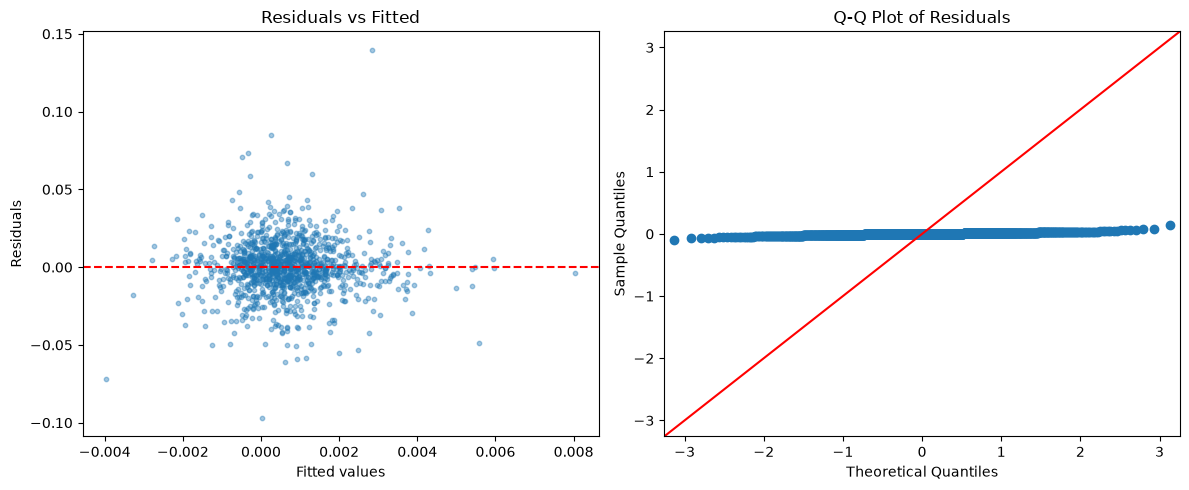

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(modelC.fittedvalues, modelC.resid, alpha=0.4, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(modelC.resid, line="45", ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

### Discussion and Model Selection

All three models now use **only information available before day $t$** (Stage 1's
contemporaneous `IXIC_t` is gone), so this section is a genuine test of whether AAPL's return
is *forecastable* from past data.

**Model A (full lagged, 10 standardized predictors, $N=1156$):** $R^2 = 0.010$,
Adj. $R^2 = 0.001$, overall F-test $p = 0.336$ -- **not significant**. The only individually
significant predictor is `VolumeChg_lag1` ($p = 0.031$); everything else (`IXIC_lag1`,
`AAPL_lag1`, all three `MA`/`Vol` horizons, `VolumeRatio_lag1`) has $p > 0.1$. All VIFs are
below 5 (max $\approx 3.4$ for `Vol50`), so multicollinearity is not the reason -- these
features simply carry no information about $\text{AAPL}_t$.

**Model B (reduced, `IXIC_lag1` + `AAPL_lag1`):** $R^2 = 0.0012$, Adj. $R^2 = -0.0006$,
$p = 0.506$ -- also not significant, and neither coefficient is significant individually
($p = 0.383$ and $p = 0.243$). This mirrors Stage 1's Model 2 finding (lagged index has zero
predictive power), now extended to include AAPL's own lagged return as well.

**Model C (volume-focused, `AAPL_lag1` + `VolumeChg_lag1` + `VolumeRatio_lag1`):**
$R^2 = 0.0046$, Adj. $R^2 = 0.0020$, $p = 0.152$ -- still not significant overall, but
`VolumeChg_lag1` is individually significant ($p = 0.032$, coefficient $-0.0013$).

**Model comparison (AIC / BIC):**

| Model | $R^2$ | Adj. $R^2$ | F-test $p$ | AIC | BIC |
|---|---|---|---|---|---|
| A (full lagged) | 0.010 | 0.001 | 0.336 | $-6053.4$ | $-5997.9$ |
| B (reduced) | 0.001 | $-0.001$ | 0.506 | $-6059.5$ | $-6044.3$ |
| C (volume-focused) | 0.005 | 0.002 | 0.152 | $-6061.4$ | $-6041.2$ |

Model C has the lowest AIC and Model B has the lowest BIC, but the differences ($\Delta\text{AIC} \approx 2$,
$\Delta\text{BIC} \approx 3$) are too small to be meaningful, and Model A is clearly worst on
both criteria (most parameters, no gain in fit). **No model is a useful forecasting tool** --
$R^2$ never exceeds 1%, and none of the three pass the overall F-test at the 5% level.

**Residual diagnostics (Model C):** Durbin-Watson $\approx 2.00$ (no autocorrelation), but
Jarque-Bera strongly rejects normality and kurtosis $\approx 8.7$ indicates heavy tails --
the same fat-tailed pattern seen in Stage 1, typical of daily financial returns and largely
independent of which (weak) model is used.

**Answers to the Part I questions:**

- **"Can market index returns explain individual stock returns?"** -- Yes, but only
  *contemporaneously*. Stage 1 Model 1 ($\text{IXIC}_t$) gave $R^2 = 0.584$. Here, with the
  index lagged by one day (Models A and B), `IXIC_lag1` is not significant ($p = 0.245$ and
  $p = 0.383$) and $R^2$ collapses to essentially zero. The relationship is real but
  simultaneous, not predictive.

- **"Can past returns help predict future returns?"** -- No. This is the central question
  of Stage 2/3 once every predictor is moved to $t-1$. Across three different specifications
  -- a 10-predictor "kitchen sink" (Model A), a minimal index+own-lag model (Model B), and a
  volume-focused model (Model C) -- the overall F-test is never significant ($p$ between
  $0.15$ and $0.51$) and $R^2$ never exceeds $1\%$. This reinforces Stage 1 Model 2's finding
  (lagged index has zero predictive power) and extends it to own lagged returns, moving
  averages and volatility at 20/50/200-day horizons: **none of them help predict tomorrow's
  return**, consistent with the weak-form Efficient Market Hypothesis.

- **"Can trading volume explain/predict returns?"** -- At best, weak and inconclusive
  evidence. `VolumeChg_lag1` (yesterday's change in trading volume) is individually
  significant at $p \approx 0.03$ in both Model A and Model C, with a small negative
  coefficient ($-0.0013$ in standardized units). However, the *overall* Model C is not
  significant ($p = 0.152$, $R^2 = 0.0046$), and with 10 predictors tested in Model A, a
  single hit at $p \approx 0.03$ is roughly what would be expected by chance alone. There is
  no robust evidence that trading volume changes explain or predict AAPL's next-day return.

- **"Can one stock's returns explain another's?"** -- Answered in Stage 1 (Model 3:
  $\text{GOOGL}_t \to \text{AAPL}_t$, $R^2 = 0.314$, contemporaneous). This Stage 2/3 analysis
  focuses on lagged, single-stock forecasting and does not revisit cross-stock predictors.

**Overall conclusion:** Stage 1 showed that AAPL's return is strongly tied to *same-day*
market and peer-stock movements ($R^2 \approx 0.31$--$0.58$). Stage 2/3 shows that none of
that explanatory power survives once everything is shifted to $t-1$ -- past prices, returns,
moving averages, volatility, and trading volume all fail to predict tomorrow's return. Taken
together, the results are consistent with (weak-form) market efficiency: information is
priced in immediately, leaving no exploitable pattern in lagged data.